In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset
df = pd.read_csv('/Users/caleb/Desktop/ds-studio-ii/DataSets/water_potability.csv')

In [18]:
#Fill in missing values with the mean of each column
df.fillna(df.mean(), inplace=True)

ppm: parts per million  
μg/L: microgram per litre  
mg/L: milligram per litre  

1. ph: pH of 1. water (0 to 14).  
2. Hardness: Capacity of water to precipitate soap in mg/L.  
3. Solids: Total dissolved solids in ppm.  
4. Chloramines: Amount of Chloramines in ppm.  
5. Sulfate: Amount of Sulfates dissolved in mg/L.  
6. Conductivity: Electrical conductivity of water in μS/cm.  
7. Organic_carbon: Amount of organic carbon in ppm.  
8. Trihalomethanes: Amount of Trihalomethanes in μg/L.  
9. Turbidity: Measure of light emiting property of water in NTU.  
10. Potability: Indicates if water is safe for human consumption. Potable -1 and Not potable -0  

In [19]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


Dataset has 10 columns and 3276 Rows.

In [20]:
df.shape

(3276, 10)

Three Random Forest Experiments.  
Experiment 1 (Baseline): Uses Mean Imputation and default Random Forest parameters. This represents a standard starting point for a data science project.  

Experiment 2 (Preprocessing & Depth):  
Uses Median Imputation (more robust to outliers in water quality) and limits the max_depth to 15. This is an experiment in regularization to prevent the model from overfitting.  

Experiment 3 (Handling Class Imbalance):  
Uses Median Imputation and sets class_weight='balanced'. Since about 60% of the dataset is "Non-Potable," this experiment tests if penalizing the model more for missing "Potable" cases improves the F1-score.  

In [ ]:
# EXPERIMENT 1: Baseline (Mean Imputation, Default RF)
from sklearn.metrics import f1_score


df_mean = df.copy()
df_mean.fillna(df_mean.mean(), inplace=True)
X1 = df_mean.drop('Potability', axis=1)
y1 = df_mean['Potability']
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train1, y_train1)
pred1 = rf_baseline.predict(X_test1)
res1 = {'Experiment': 'Exp 1: Baseline (Mean)', 'Accuracy': accuracy_score(y_test1, pred1), 'F1': f1_score(y_test1, pred1)}


In [ ]:
# EXPERIMENT 2: Median Imputation + Tuning
df_median = df.copy()
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    df_median[col].fillna(df_median[col].median(), inplace=True)

X2 = df_median.drop('Potability', axis=1)
y2 = df_median['Potability']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Experimenting with deeper trees and more estimators
rf_tuned = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf_tuned.fit(X_train2, y_train2)
pred2 = rf_tuned.predict(X_test2)
res2 = {'Experiment': 'Exp 2: Median + Tuning', 'Accuracy': accuracy_score(y_test2, pred2), 'F1': f1_score(y_test2, pred2)}

/var/folders/ts/64c8tt8j51dc4x1svk9mtsv80000gn/T/ipykernel_17487/4228746387.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_median[col].fillna(df_median[col].median(), inplace=True)
/var/folders/ts/64c8tt8j51dc4x1svk9mtsv80000gn/T/ipykernel_17487/4228746387.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [ ]:
# EXPERIMENT 3: Class Weight Optimization
# Addressing class imbalance directly within the RF algorithm
rf_balanced = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train2, y_train2)
pred3 = rf_balanced.predict(X_test2)
res3 = {'Experiment': 'Exp 3: Balanced RF', 'Accuracy': accuracy_score(y_test2, pred3), 'F1': f1_score(y_test2, pred3)}

               Experiment  Accuracy        F1
0  Exp 1: Baseline (Mean)  0.661585  0.412698
1  Exp 2: Median + Tuning  0.667683  0.394444
2      Exp 3: Balanced RF  0.657012  0.386921


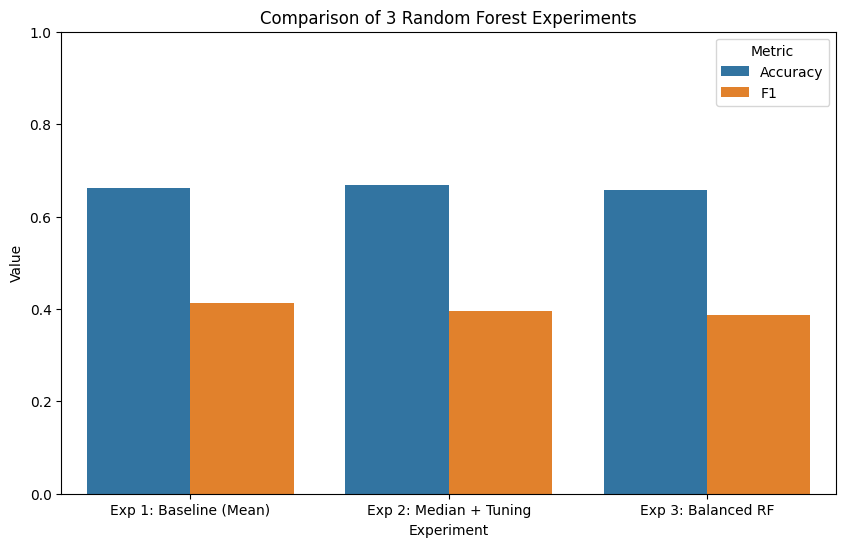

In [ ]:
# Comparison & Analysis
results_df = pd.DataFrame([res1, res2, res3])

# Plotting the Comparison (Rubric Requirement)
plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars='Experiment', var_name='Metric', value_name='Value')
sns.barplot(data=results_melted, x='Experiment', y='Value', hue='Metric')
plt.title('Comparison of 3 Random Forest Experiments')
plt.ylim(0, 1)
plt.savefig('rf_experiments_comparison.png')

print(results_df)